In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder  , StandardScaler
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.linear_model import Perceptron # Used for simple linear classification tasks 
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix



from tensorflow.keras.models import Sequential # Sequential lets you buils a neueal network layer by layer in keras 

from tensorflow.keras.layers import Dense #Dense makes the final predictions
from tensorflow.keras.layers import Conv2D # Conv2D extracts features
from tensorflow.keras.layers import Flatten # Flatten reshapes them

from tensorflow.keras.layers import MaxPooling2D # MaxPooling2D reduces size
from tensorflow.keras.layers import Dropout          # Dropout prevents overfitting

from tensorflow.keras.utils import to_categorical     # converts numeric class labels into one-hot encoded format for training classification models
     

In [3]:
df = pd.read_csv("mnist_train.csv")
df_test = pd.read_csv("mnist_test.csv")

In [4]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df_test.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.shape

(60000, 785)

In [7]:
df.columns

Index(['label', '1x1', '1x2', '1x3', '1x4', '1x5', '1x6', '1x7', '1x8', '1x9',
       ...
       '28x19', '28x20', '28x21', '28x22', '28x23', '28x24', '28x25', '28x26',
       '28x27', '28x28'],
      dtype='object', length=785)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [9]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

In [10]:
#preprocess 
X_train=df.drop("label", axis =1).values
y_train =df["label"].values
X_test=df_test.drop("label",axis=1).values
y_test=df_test["label"].values

In [12]:
# Converts pixel values from int → float32 (needed for neural networks)
# Scales from 0–255 → 0.0–1.0 (helps the model train faster and converge better)

X_train=X_train.astype("float32") /255.00
X_test=X_test.astype("float32") /255.0

In [13]:
X_train_img = X_train.reshape(-1, 28, 28, 1)
X_test_img = X_test.reshape(-1, 28, 28, 1)

# This converts flat 784 pixels → 28×28×1 image format that Conv2D expects.
# -1 means "figure out how many samples automatically".
# 28, 28 is the image height and width.
# 1 is the number of color channels (1 = grayscale; an RGB image would be 3).



In [14]:
# Converts labels like 5 → [0, 0, 0, 0, 0, 1, 0, 0, 0, 0] 
# (one-hot encoding for 10 classes: digits 0–9).


y_train_cat=to_categorical(y_train,10)
y_test_cat = to_categorical(y_test, 10)


In [15]:
y_train_cat

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

In [16]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10, activation="softmax")
])

In [17]:
perceptron.compile(optimizer="sgd", loss="categorical_crossentropy", metrics=["accuracy"])

In [18]:
history_precp= perceptron.fit(X_train_img,y_train_cat,epochs=5,
batch_size=32,validation_data=(X_test_img , y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.8149 - loss: 0.7738 - val_accuracy: 0.8785 - val_loss: 0.4815
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8796 - loss: 0.4568 - val_accuracy: 0.8946 - val_loss: 0.4008
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8908 - loss: 0.4038 - val_accuracy: 0.9016 - val_loss: 0.3684
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8964 - loss: 0.3772 - val_accuracy: 0.9048 - val_loss: 0.3491
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9005 - loss: 0.3604 - val_accuracy: 0.9081 - val_loss: 0.3367


In [19]:
acc_percep= perceptron.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [20]:
acc_percep

0.9081000089645386

# ANN

In [21]:
ann=Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation="relu"),
    Dense(64,activation="relu"),
    Dense(10,activation="softmax")
])

In [22]:
ann.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [25]:
history_ann=ann.fit(X_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(X_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.9694 - loss: 0.1004 - val_accuracy: 0.9723 - val_loss: 0.0903
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9783 - loss: 0.0691 - val_accuracy: 0.9731 - val_loss: 0.0881
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9833 - loss: 0.0536 - val_accuracy: 0.9748 - val_loss: 0.0832
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.9861 - loss: 0.0420 - val_accuracy: 0.9724 - val_loss: 0.0887
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.9883 - loss: 0.0356 - val_accuracy: 0.9729 - val_loss: 0.0951


In [26]:
acc_ann=ann.evaluate(X_test_img,y_test_cat,verbose=0)[1]

In [27]:
acc_ann

0.9728999733924866

# CNN

In [28]:
X_train_cnn=X_train.reshape(-1,28,28,1)
X_test_cnn=X_test.reshape(-1,28,28,1)

What it does: Converts the flat 784-pixel array back into a 28×28 image with 1 color channel (grayscale).

Why: Conv2D needs 4D input → (num_samples, height, width, channels). A regular Dense layer works with flat 1D data, but convolution layers need to understand the spatial arrangement (which pixel is next to which) — that's why we reshape into a 2D grid.

In [ ]:
cnn=Sequential([

    Conv2D(32,kernel_size=(3,3),activation="relu",
    input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),  

    Conv2D(64,kernel_size=(3,3),activation="relu"),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

Layer 1 — Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1))


32	--> Create 32 different filters — each one learns to detect a different feature (edges, curves, corners, etc.)

(3,3)	--> Each filter is a 3×3 window that slides across the image

activation='relu'	--> After convolution, apply ReLU — turns all negative values to 0. This adds non-linearity so the network can learn complex patterns

input_shape=(28,28,1)	--> Tells the model: "First layer expects a 28×28 grayscale image"


Output shape: (26, 26, 32) — because (28-3)+1 = 26, and we have 32 filters.

Analogy: 32 detectives, each with a 3×3 magnifying glass, scanning the image for different clues.

Layer 2 — MaxPooling2D((2,2))



(2,2)       --> Takes a 2×2 window, picks the maximum value from those 4 pixels



What it does: Shrinks each feature map by half → (26,26,32) becomes (13,13,32).


Why:

Reduces computation (fewer pixels to process)
Keeps only the strongest features (the max values)
Makes the model more translation invariant — if the digit shifts a little, maxpool still picks it up

Layer 3 — Conv2D(64, (3,3), activation='relu')
        
64	--> Now 64 filters — more filters to detect more complex patterns
(3,3)	--> Same 3×3 window

Output shape: (11, 11, 64) — because (13-3)+1 = 11.

Why 64 (more than 32)? Deeper layers detect more complex features (shapes, parts of digits). More filters = more types of features it can learn. Layer 1 finds edges → Layer 3 finds shapes made from those edges.

Layer 4 — MaxPooling2D((2,2)))
Same as before — shrinks (11,11,64) → (5,5,64).

Layer 5 — Flatten()
What it does: Converts the 3D feature map (5, 5, 64) into a 1D vector of 5 × 5 × 64 = 1600 values.

Why: The Dense (fully connected) layer can only work with 1D input. This is the bridge between CNN layers and ANN layers.

Analogy: The detectives collected all their clues (3D maps). Now they write them in one long list and hand it to the decision maker.

Layer 6 — Dense(128, activation='relu')

128	--> 128 neurons in a fully connected hidden layer

relu	--> Activation function — keeps positive values, kills negatives

Why: This layer combines all the features extracted by Conv layers and learns which combinations of features mean which digit. It's the "thinking" layer.

In [31]:
cnn.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [34]:
history_cnn=cnn.fit(X_train_cnn,y_train_cat,epochs=5,batch_size=32,
            validation_data=(X_test_cnn,y_test_cat), verbose=1
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 25s 13ms/step - accuracy: 0.9898 - loss: 0.0328 - val_accuracy: 0.9896 - val_loss: 0.0328
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9912 - loss: 0.0284 - val_accuracy: 0.9907 - val_loss: 0.0308
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9920 - loss: 0.0248 - val_accuracy: 0.9919 - val_loss: 0.0281
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9926 - loss: 0.0222 - val_accuracy: 0.9926 - val_loss: 0.0258
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9934 - loss: 0.0202 - val_accuracy: 0.9922 - val_loss: 0.0282


In [35]:
acc_cnn=cnn.evaluate(X_test_cnn,y_test_cat,verbose=0)[1]

In [36]:
acc_cnn

0.9922000169754028

In [43]:
def plot_training(history, title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label="Train")
    plt.plot(history.history['val_accuracy'], label="Val")
    plt.title(f"{title} Accuracy")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label="Train")
    plt.plot(history.history['val_loss'], label="Val")
    plt.title(f"{title} Loss")
    plt.legend()
    plt.show()


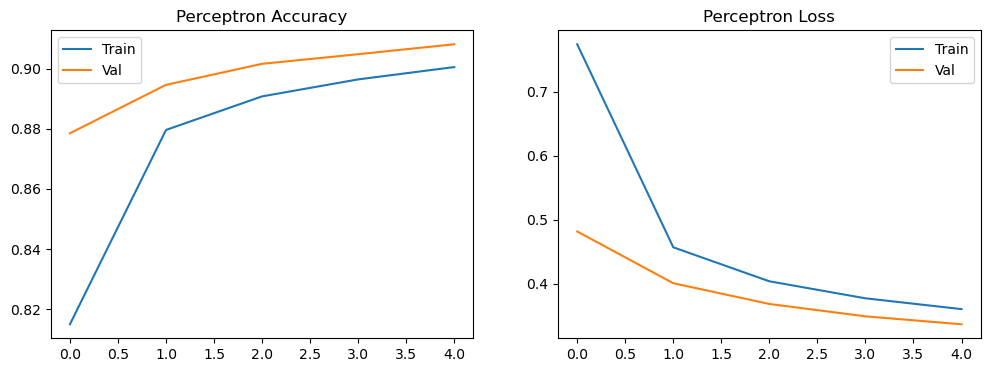

In [45]:

plot_training(history_precp, "Perceptron")

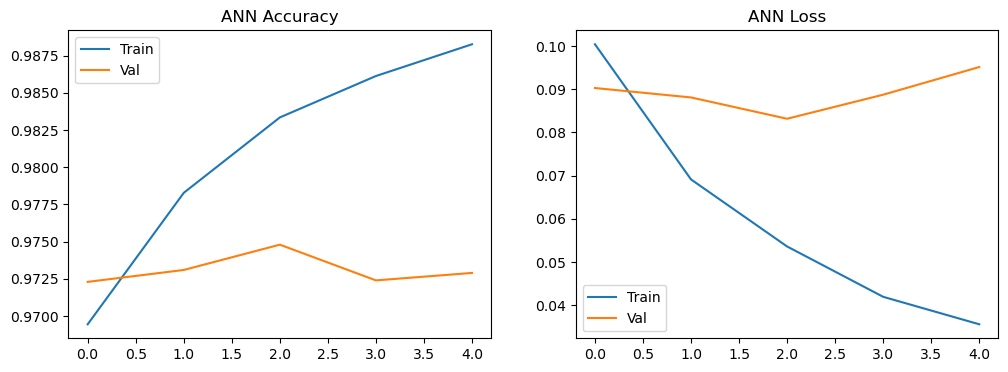

In [46]:
plot_training(history_ann, "ANN")

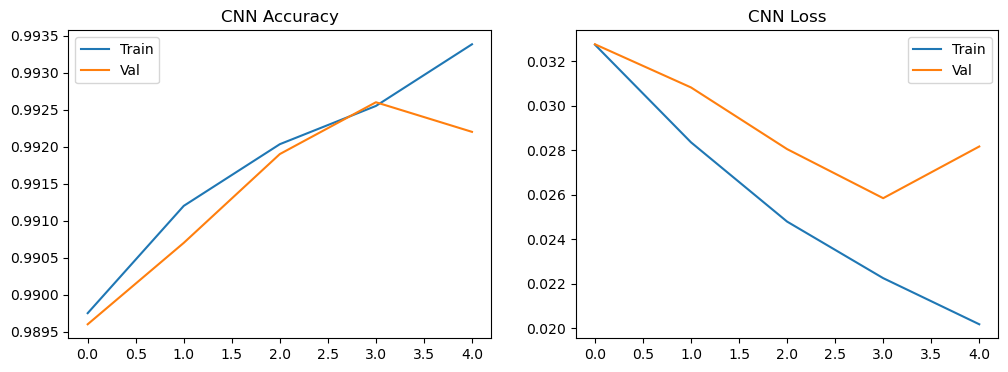

In [47]:


plot_training(history_cnn, "CNN")

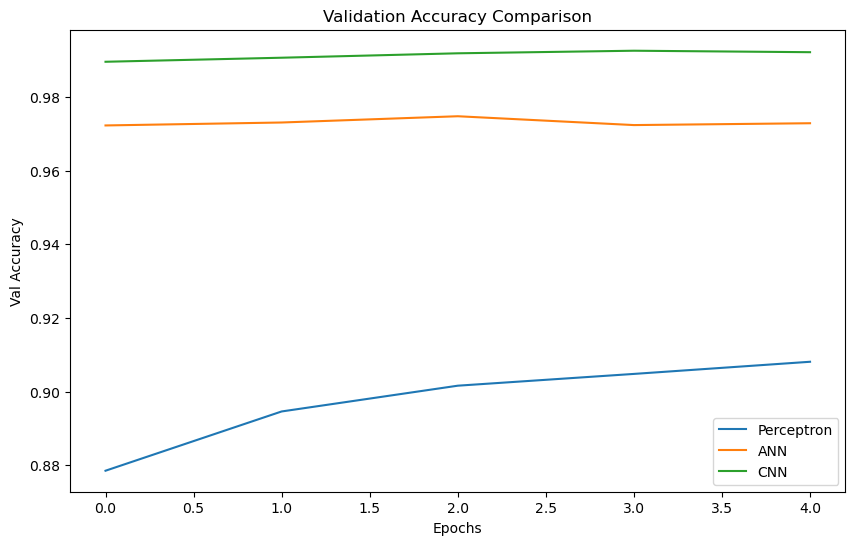

In [49]:
plt.figure(figsize=(10,6))
plt.plot(history_precp.history['val_accuracy'], label="Perceptron")
plt.plot(history_ann.history['val_accuracy'], label="ANN")
plt.plot(history_cnn.history['val_accuracy'], label="CNN")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()
     

In [50]:
def show_side_by_side(models, model_names, X, X_cnn, y_true, n=5):
    idxs = np.random.choice(len(X), n, replace=False)
    plt.figure(figsize=(15, 6))
    for i, idx in enumerate(idxs):
        plt.subplot(2, n, i+1)
        plt.imshow(X[idx].reshape(28, 28), cmap="gray")
        plt.axis("off")
        plt.title(f"True: {y_true[idx]}")
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1, 28, 28, 1) if name == "CNN" else X[idx].reshape(1, 28, 28)))
                 for model, name in zip(models, model_names)]
        plt.subplot(2, n, n+i+1)
        plt.axis("off")
        plt.title("\n".join(f"{n}: {p}" for n, p in zip(model_names, preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 306ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step


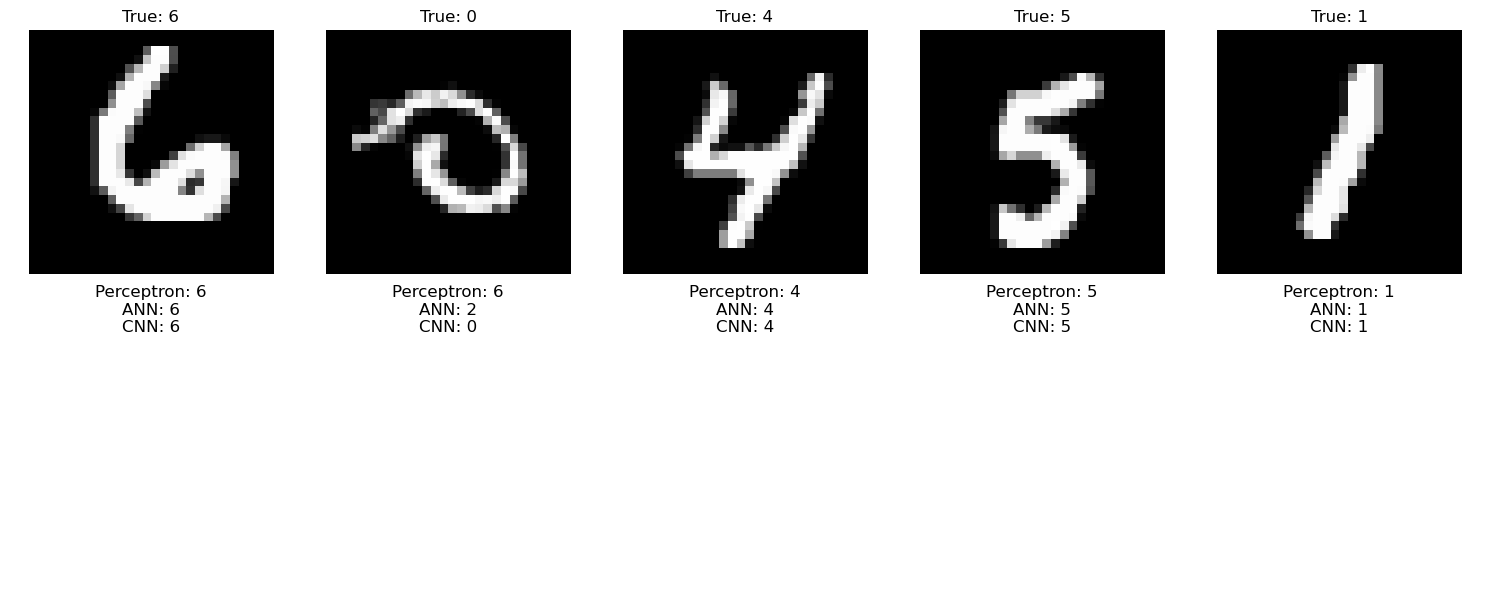

In [51]:
show_side_by_side([perceptron, ann, cnn], ["Perceptron", "ANN", "CNN"], X_test_img, X_test_cnn, y_test, 5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


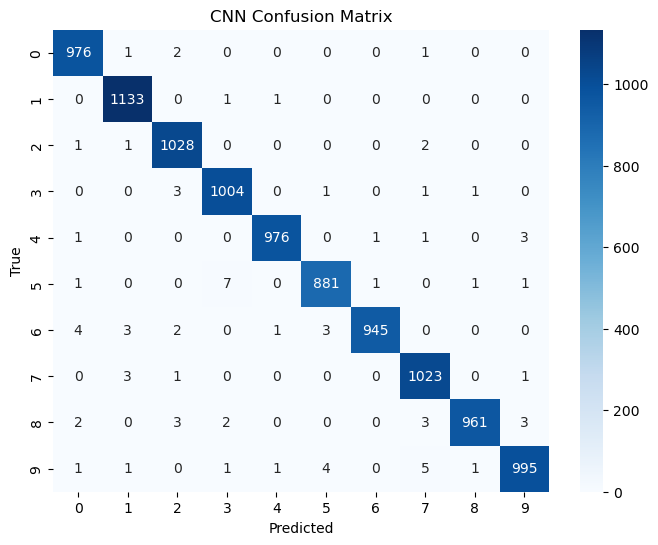

In [52]:

y_pred_cnn = np.argmax(cnn.predict(X_test_cnn), axis=1)
cm = confusion_matrix(y_test, y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("CNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

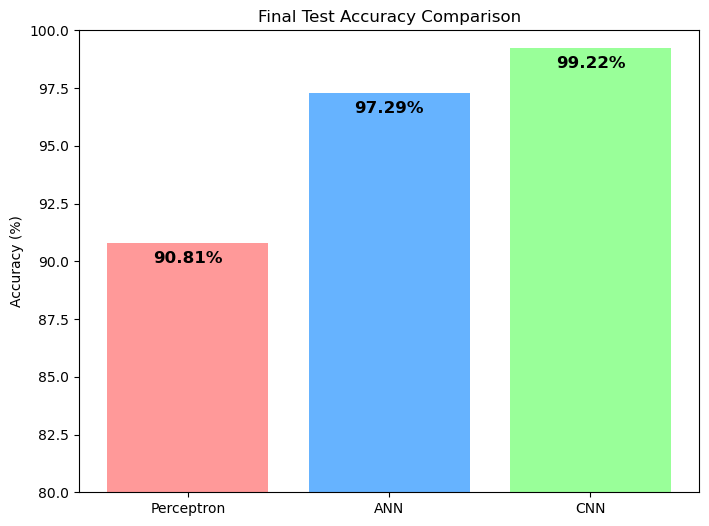

In [54]:
final_accs = [acc_percep*100, acc_ann*100, acc_cnn*100]
models = ["Perceptron", "ANN", "CNN"]

plt.figure(figsize=(8,6))
bars = plt.bar(models, final_accs, color=['#ff9999','#66b3ff','#99ff99'])
plt.title("Final Test Accuracy Comparison")
plt.ylabel("Accuracy (%)")
for bar, acc in zip(bars, final_accs):
    plt.text(bar.get_x()+bar.get_width()/2, bar.get_height()-1, f"{acc:.2f}%",
             ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.ylim(80, 100)
plt.show()